In [ ]:
 #@title **code** Coding a DNN from Keras

model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28, 28, 1]),#ESTA CAPA APLANA LA IMAGEN DEJANDOLA COMO UN VECTOR Input, lo vectoriza
    tf.keras.layers.Dense(128, activation=tf.nn.relu),#Hidden
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Output, la softmax pasa numeros que no son tan interpretables a probabilidades. EN clasiifcacion es las son cantidad de neuronas y softmax para que me diga cada una cual es la clase. En este caso, 10 neuronas para las 10 clases de digitos.
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/banner_IA.png"  width="1000px" height="250px">

# <center> **12. A brief and very preliminary introduction to deep learning!** </center>


This guide uses tf.keras, a high-level API to build and train models in TensorFlow.


##  **Outline**
1. [**DL: The most simple linear model**](#eje1)
2. [**DL: The engineering solution and activation functions**](#eje2)
3. [**DL: Training, Back-propagation and gradient descent**](#eje3)
4. [**DL: Testing: Forward propagation**](#eje4)

In [1]:
#@title **Execute this cell**
#@markdown Please include your student id
import sys
import inspect

group_id = "IA1-20252-C1" #@param {type:"string"}
assignment_id = group_id +'.deep_learning_intro'
student_id = "2211233" #@param {type:"string"}
"""
Put your student ID here

Example: student_id =  '2152145'
"""

"\nPut your student ID here\n\nExample: student_id =  '2152145'\n"

In [2]:
#@title **Execute this cell**
#@markdown **UTILS**
#@markdown Please dont modify any line in this cell

import os
import json
import requests
from collections import namedtuple


Config = namedtuple('Config', ['server_name'])
config = Config(server_name='https://bivlabgrader.azurewebsites.net/api')


def check_solution_and_evaluate(assignment_id: str, student_func_str: str):

    # Set the endpoint and payload.
    payload = {
        'func_str': student_func_str,
        'assignment_id': assignment_id,
        'student_id': student_id
    }
    endpoint_url = config.server_name + '/CheckAndEvaluateSolution'
    # print(endpoint_url)

    # Make request to server with the data coming from the notebook.
    r = requests.post(endpoint_url, params=payload)
    pprint_json_response(r.json())
    return r


def pprint_json_response(response, indent=0):
    """Pretty print the response."""
    for key, value in response.items():
        print('\t' * indent + str(key.capitalize()))

        # If dictionary, do a recurrent call.
        if isinstance(value, dict):
            pprint_json_response(value, indent + 1)
        else:
            # Enumerate elements if list.
            if isinstance(value, list):
                if len(value) == 1:
                    print('\t' * (indent + 1) + str(value[0]))
                else:
                    for i, e in enumerate(value, start=1):
                        print('\t' * (indent + 1) + f'{i}. {e}')
            else:
                print('\t' * (indent + 1) + str(value))

In [3]:
#@title **MONTAR EL DRIVE** { display-mode: "form" }
import os
from google.colab import drive

path_ai = "/ai-uis-student-master" #@param {type:"string"}
path = "/content/drive/My Drive/" + path_ai
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/ai-uis-student-master


In [4]:
#@title 2. LOAD LIB { display-mode: "form" }
#@markdown Here is important to change to GPU

import tensorflow as tf
from tensorflow import keras
print(tf.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2.19.0


# **1. DL: The most simple linear model** <a name="eje1"></a>


The **most sucesful** thecnique nowadays is based on the most simple classifier: **the linear classifier!**. The basic idea is to split classes by a linear boundary with dimensions according to the features of the problem.

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/img0.png"/>


- It is the most simple classifer, from which the predicted value $\hat{y}$ is represented as a **linear combination** of input variables $\mathbf{X} = [x_1, x_2, \ldots, x_n]$, so:

$$\hat{y}(W, X) = w_0 + x_1 w_1+ x_2 w_2+ \ldots + x_n w_n$$

  - ($x_i$) Inputs: image features, pixels  
  - ($W$) Weights associated to each of the fetures
  - ($\hat{y}$) predictions label. {cat, garfield, car ...}
     
**How?:**

- Fit a linear model with coefficients $w = (w_0, \ldots, w_p)$ minimizing the residual sum of squares:

$$min_{\mathbf{w}} ||\mathbf{X}w -y ||_{2}^{2}$$

**THE PROBLEM NOW IS TO FIND $\mathbf{w}$**

### This linear equation could be represented as a network:


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/dl1.jpg" >



Why a relationship with **biological neurons**

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/singleN.png" >


**Go to the action!**

## **An example with image classification**

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/imageClassification.jpeg" alt="Drawing" style="width:1700px;">

## **MNIST dataset**

The well know classification: MNIST dataset with 60000 images for training and 10000 for test. Images were taken from American Census Bureau employees and American high school students.

**Note:** This original dataset is much larger than previous one!

In [5]:
#@title **code** Download original Mnist
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print (x_train.shape, y_train.shape, x_test.shape, y_test.shape)
print(tf.__version__)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
2.19.0


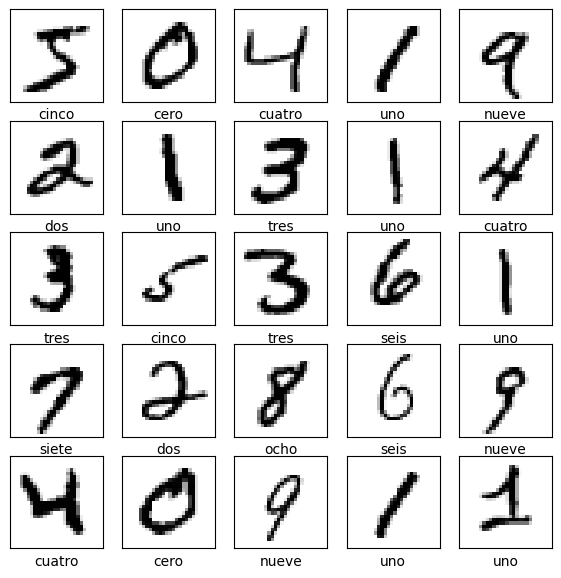

In [6]:
#@title **code** To plot some examples
class_names = ['cero','uno', 'dos', 'tres', 'cuatro', 'cinco', 'seis', 'siete', 'ocho', 'nueve']
plt.figure(figsize=(7,7))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])

In [7]:
#@title **code** To normalize and prepare data
x_train = x_train.reshape([-1, 28, 28, 1])
x_test = x_test.reshape([-1, 28, 28, 1])

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print('Number of images in x_train', x_train.shape[0])
print('Number of images in x_test', x_test.shape[0])

x_train shape: (60000, 28, 28, 1)
Number of images in x_train 60000
Number of images in x_test 10000


In [8]:
x_train.shape


#que hace??
sample = x_train[0]
sample.shape

print(sample.shape, np.prod(sample.shape))

#aplanar el ejemplo
#EXPLICA COMO SE PLANO ARRIBA


(28, 28, 1) 784


# **2. DNN: The engineering solution: hidden layers and activation functions**
<a name="eje2"></a>

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/ANNs.gif" style="width:400px;">

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/dl2.jpg" style="width:300px;">



## **Main componenets on DNN**


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/banner_dl.png" alt="Drawing" style="width:1700px;">


- **input units:**  are raw information as input layer, namely a vectorized version of each sample. For MNIST is a flatten vector of 784 inputs.
- **Hidden units:** are internal correlation on the network, which do the **magic!**. The input units and previous layers are correllated wit some **learned weights**.
- **activation functions:** introduce non-linearity into the output of a neuron. This is important because most real world data is non linear and we want neurons to learn these non linear representations.
    - *Softmax*, used in classification tasks, takes a vector of arbitrary real-valued scores and squashes it to a vector of values between zero and one to ensure that the outputs are probabilities.
    
    
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/actifunc.png" >


- **output units** Give the result on correlation of network units, and namelly is mapped to a **sofmax function** to give a probability of each class. On MNIST sample the output layer should be 10 because we have 10 classes.

In [11]:
#@title **code** Coding a DNN from Keras

model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28, 28, 1]),#ESTA CAPA APLANA LA IMAGEN DEJANDOLA COMO UN VECTOR Input, lo vectoriza
    tf.keras.layers.Dense(128, activation=tf.nn.relu),#Hidden
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Output, la softmaxpasa numeros que no son tan interpretables a probabilidades . EN clasiifcacion es las son cantidad de neuronas y softmax para que me diga cada una cual es la clase
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# **3. DL: Training, Back-propagation and gradient descent** <a name="eje3"></a>

For **training** is used a backpropagation strategy, which consist on compute derivatives from end-to-start into the network. The backpropagation is implemented using a thecnique named **Gradient Descent**, which ‘adjust’ all weights in the network with an aim of reducing the error at the output layer.



- **Backpropagation** best trade-off between intuition and formalism [here](http://home.agh.edu.pl/~vlsi/AI/backp_t_en/backprop.html)


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/dl3.gif" >


- **Stochastic gradient descent:**  select randomly a sub-set for training  because the high dimensional problem on DNN
- **Epochs** number of times that an **ENTIRE** dataset is passed orward and backward through the DNN
- **Batch size** is the sub-set of training examples to pass into during gradient descent training. For stochastic gradient descent is used the concep of mini-batch

In [12]:
#@title **code** Training a DNN
model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy', #se usa el sparse cuando es un modelo con etiquetas de numeros enteros en Tf keras
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)#epoch es la cantidad de veces que el modelo vio todo mi conjunto de datos

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7390 - loss: 1.0112
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9020 - loss: 0.3531
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9151 - loss: 0.2991
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9271 - loss: 0.2626
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9326 - loss: 0.2431


In [14]:
probabilidades = model.predict()

NameError: name 'y_pred' is not defined

# **4. DL: Testing: Forward propagation** <a name="eje4"></a>

Once we have trained our DNN, we follow a classical evaluation of a machine learning dataset. In such case we will to evaluate the accuracy:

In [15]:
#@title **code** Evaluating the model
test_loss, test_acc = model.evaluate(x_test, y_test)

print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9282 - loss: 0.2527
Test accuracy: 0.9377999901771545


see more deeply on predictions

In [17]:
#@title **code** How work predictions?
predictions = model.predict(x_test)
print(predictions[5125])
print("valor predicho:",  np.argmax(predictions[5125]), "max prob: ", np.max(predictions[5125]),
      "ground truth: ", y_test[5125] )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[2.3990027e-05 6.3167880e-07 9.9789304e-01 3.1347285e-05 1.4295524e-07
 4.6598849e-05 4.4744153e-05 6.6829411e-06 1.9470230e-03 5.7970278e-06]
valor predicho: 2 max prob:  0.99789304 ground truth:  2


In [20]:
#importar la metrica
from sklearn.metrics import accuracy_score

#convertir las probabilidades a etiquetas
etiquetas_predichas = np.argmax(predictions, axis=1)
etiquetas_reales = y_test

#calcular la precisión y compraramos las etiquetas predichcas con las verdaderas
accuracy = accuracy_score(y_test, etiquetas_predichas)



print("Accuracy", accuracy)
#crea una matriz de confusion
from sklearn.metrics import confusion_matrix
print(predictions.shape)
labels_pred = np.argmax(predictions, axis=1)
cm_test = confusion_matrix(y_test, labels_pred)
print ("matrix de confusión en test\n", cm_test)


Accuracy 0.9378
(10000, 10)
matrix de confusión en test
 [[ 962    0    0    2    0    3    7    2    4    0]
 [   0 1111    2    2    1    1    3    1   14    0]
 [  10    3  944   13   10    1   11   13   23    4]
 [   2    1   19  929    0   22    1   14   17    5]
 [   1    1    3    1  928    0   13    2    9   24]
 [  10    2    1   25    6  802   17    4   19    6]
 [   8    3    3    2   11   11  917    1    2    0]
 [   3   10   22    7    6    0    0  958    3   19]
 [   3    4    4   16    8   14    8    9  905    3]
 [   9    8    1   10   34    5    1   10    9  922]]


Now, we can evaluate single examples, even new examples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
the number predicted is:  2


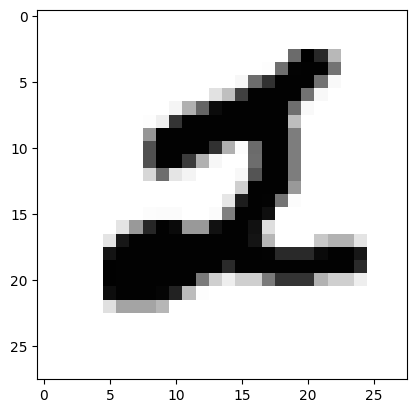

In [21]:
#@title **code** individual predictions
img_rows, img_cols =28, 28
image_index = 5125
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
pred = model.predict(x_test[image_index].reshape(1, img_rows, img_cols, 1))
print("the number predicted is: ", pred.argmax())# argmax toma el valor mas alto del array de salida

<Figure size 640x480 with 0 Axes>

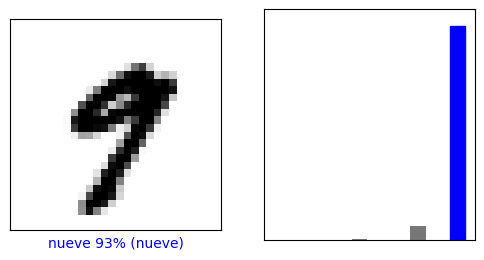

In [22]:
#@title **code** Performance on predictions
%run code/dl_plot.py
i = 20
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  y_test)

<Figure size 640x480 with 0 Axes>

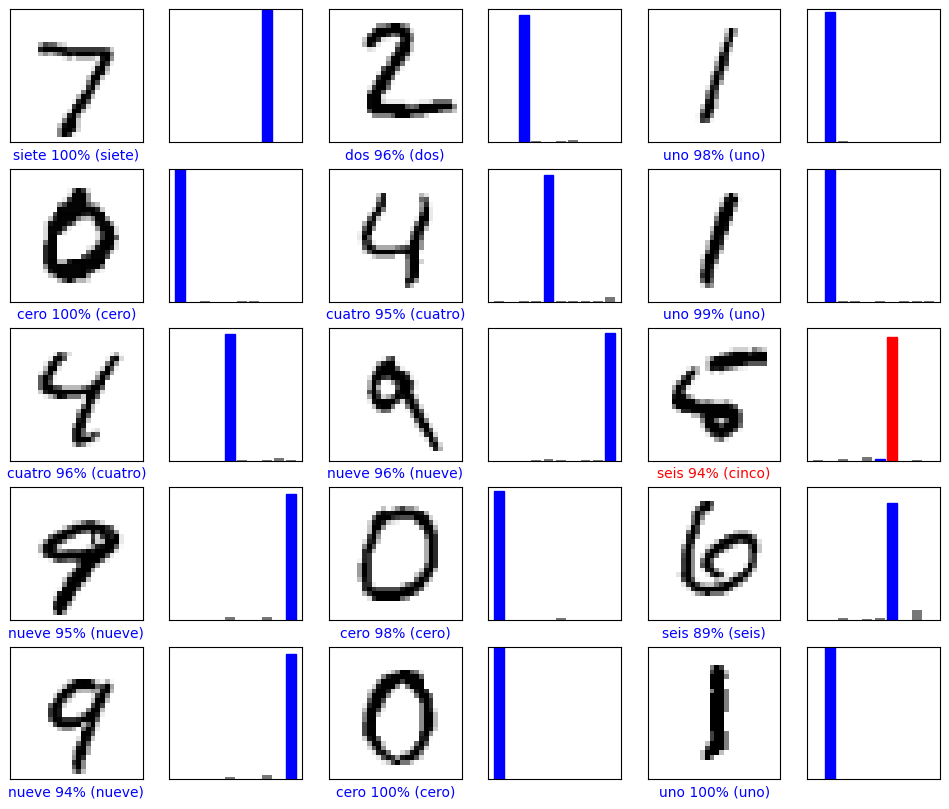

In [24]:
#@title **code** Batch of predictions
%run code/dl_plot.py
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, y_test, x_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions, y_test)

(10000, 10)
matrix de confusión en test
 [[ 962    0    0    2    0    3    7    2    4    0]
 [   0 1111    2    2    1    1    3    1   14    0]
 [  10    3  944   13   10    1   11   13   23    4]
 [   2    1   19  929    0   22    1   14   17    5]
 [   1    1    3    1  928    0   13    2    9   24]
 [  10    2    1   25    6  802   17    4   19    6]
 [   8    3    3    2   11   11  917    1    2    0]
 [   3   10   22    7    6    0    0  958    3   19]
 [   3    4    4   16    8   14    8    9  905    3]
 [   9    8    1   10   34    5    1   10    9  922]]
verifica número de imágenes en total por fila
[ 980 1135 1032 1010  982  892  958 1028  974 1009]


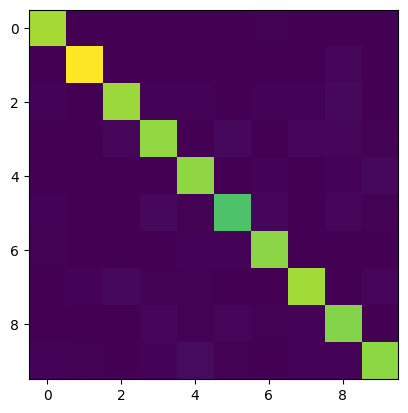

In [25]:
#@title **code** confussion matrices to underestand results
from sklearn.metrics import confusion_matrix
print(predictions.shape)
labels_pred = np.argmax(predictions, axis=1)
cm_test = confusion_matrix(y_test, labels_pred)
print ("matrix de confusión en test\n", cm_test)
print( "verifica número de imágenes en total por fila")
print( np.sum(cm_test, axis=1))
plt.imshow(cm_test)

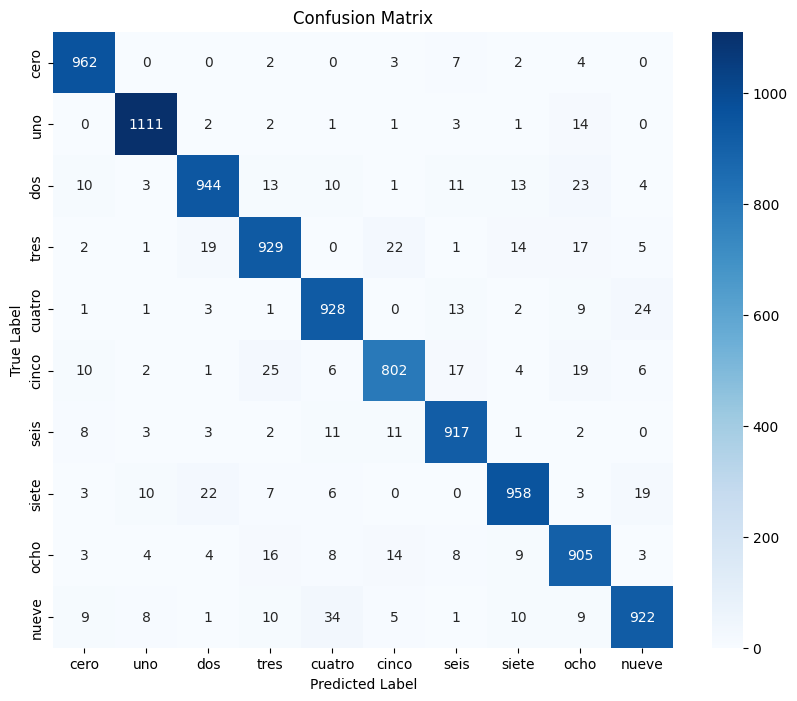

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming cm_test is already computed from the previous cell

plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">


1. Change configuration with two different activation function: tanh, elu
2. Built a deep neural network with:
    - one hidden layer of 512 neurons and relu activation
    - one hidden layers of 128.
3. Try with a more challenge dataset: for instance: **fashion mnist**



In [28]:
#@title **code student**
#1. point
#usando funcion de activacion tanh
model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28, 28, 1]),#ESTA CAPA APLANA LA IMAGEN DEJANDOLA COMO UN VECTOR Input, lo vectoriza
    tf.keras.layers.Dense(128, activation=tf.nn.tanh),#Hidden, capa oculta con funcion de activacion tanh
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Output, la softmaxpasa numeros que no son tan interpretables a probabilidades . EN clasiifcacion es las son cantidad de neuronas y softmax para que me diga cada una cual es la clase
])

model.summary()

model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy', #se usa el sparse cuando es un modelo con etiquetas de numeros enteros en Tf keras
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)#epoch es la cantidad de veces que el modelo vio todo mi conjunto de datos







test_loss, test_acc = model.evaluate(x_test, y_test)

print('Test accuracy:', test_acc)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7516 - loss: 0.9352
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8959 - loss: 0.3721
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9098 - loss: 0.3184
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9182 - loss: 0.2887
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9213 - loss: 0.2729
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9145 - loss: 0.2909
Test accuracy: 0.9262999892234802


In [31]:

#corriendo con funcion de activacion elu
model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28, 28, 1]),#ESTA CAPA APLANA LA IMAGEN DEJANDOLA COMO UN VECTOR Input, lo vectoriza
    tf.keras.layers.Dense(128, activation=tf.nn.tanh),#Hidden, capa oculta con funcion de activacion elu
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Output, la softmaxpasa numeros que no son tan interpretables a probabilidades . EN clasiifcacion es las son cantidad de neuronas y softmax para que me diga cada una cual es la clase
])

model.summary()

model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy', #se usa el sparse cuando es un modelo con etiquetas de numeros enteros en Tf keras
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)#epoch es la cantidad de veces que el modelo vio todo mi conjunto de datos







test_loss, test_acc = model.evaluate(x_test, y_test)

print('Test accuracy:', test_acc)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7530 - loss: 0.9535
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8972 - loss: 0.3711
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9120 - loss: 0.3185
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9175 - loss: 0.2891
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9235 - loss: 0.2733
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9187 - loss: 0.2903
Test accuracy: 0.9307000041007996


In [33]:
#@title **code student**
#2. point


model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28, 28, 1]),#ESTA CAPA APLANA LA IMAGEN DEJANDOLA COMO UN VECTOR Input, lo vectoriza
    tf.keras.layers.Dense(512, activation=tf.nn.relu),#Hidden, capa oculta con funcion de activacion relu
    tf.keras.layers.Dense(128),#Hidden, capa oculta sin activacion
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Output, la softmaxpasa numeros que no son tan interpretables a probabilidades . EN clasiifcacion es las son cantidad de neuronas y softmax para que me diga cada una cual es la clase
])

model.summary()

model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy', #se usa el sparse cuando es un modelo con etiquetas de numeros enteros en Tf keras
              metrics=['accuracy'])#la compilo definiendo el optimizador, funcionnde perdida y las otras metricas
model.fit(x_train, y_train, epochs=5)#epoch es la cantidad de veces que el modelo vio todo mi conjunto de datos. model








test_loss, test_acc = model.evaluate(x_test, y_test)

print('Test accuracy:', test_acc)
#lo ideal es usar funcion de activacion con una que no sea

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,874 (1.79 MB)

 Trainable params: 468,874 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7986 - loss: 0.7927
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9222 - loss: 0.2725
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9373 - loss: 0.2212
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9489 - loss: 0.1819
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9568 - loss: 0.1525
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9500 - loss: 0.1675
Test accuracy: 0.9585000276565552


# **References**

[1] Tensorflow: https://www.tensorflow.org/


[2] Playground: http://playground.tensorflow.org/


[3] Udacity deep learning course: https://classroom.udacity.com/courses/ud730

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/bannerThanks.jpg" style="width:1000px;">